In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving manufacturing_dataset_1000_samples.csv to manufacturing_dataset_1000_samples.csv


In [ ]:
df = pd.read_csv('manufacturing_dataset_1000_samples.csv', encoding='latin1')
df.head()

,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


analysis


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 1000
Columns: 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   object 
 13  Day_of_Week

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Injection_Temperature,0
Injection_Pressure,0
Cycle_Time,0
Cooling_Time,0
Material_Viscosity,20
Ambient_Temperature,20
Machine_Age,0
Operator_Experience,20
Maintenance_Hours,0


there are null values in Material_Viscosity,Ambient_Temperature,Operator_Experience


DATA CLEANING

In [ ]:
# Fill missing Material Viscosity with median

df["Material_Viscosity"] = df["Material_Viscosity"].fillna(
    df["Material_Viscosity"].median()
)
# Fill missing Ambient Temperature with median

df["Ambient_Temperature"] = df["Ambient_Temperature"].fillna(

    df["Ambient_Temperature"].median()
)
# Fill missing Operator Experience with median

df["Operator_Experience"] = df["Operator_Experience"].fillna(
    df["Operator_Experience"].median()
)

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Injection_Temperature,0
Injection_Pressure,0
Cycle_Time,0
Cooling_Time,0
Material_Viscosity,0
Ambient_Temperature,0
Machine_Age,0
Operator_Experience,0
Maintenance_Hours,0


In [ ]:
# Removing Unwanted Data
df = df.drop("Timestamp", axis=1)

In [ ]:
print(df.columns.tolist())
print("Shape:", df.shape)

['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']
Shape: (1000, 18)


EDA


In [ ]:
df.describe()


,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.452100,22.940400,7.855900,30.621300,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,72.621536,2.745813,3.900798,27.433292,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,201.850000,20.800000,4.700000,9.975000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,293.725000,25.000000,11.100000,42.725000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000


In [ ]:
print("Shift:")
print(df["Shift"].value_counts())

print("\nMachine Type:")
print(df["Machine_Type"].value_counts())

print("\nMaterial Grade:")
print(df["Material_Grade"].value_counts())

print("\nDay of Week:")
print(df["Day_of_Week"].value_counts())

Shift:
Shift
Day        517
Evening    277
Night      206
Name: count, dtype: int64

Machine Type:
Machine_Type
Type_A    384
Type_B    347
Type_C    269
Name: count, dtype: int64

Material Grade:
Material_Grade
Standard    591
Premium     210
Economy     199
Name: count, dtype: int64

Day of Week:
Day_of_Week
Friday       168
Wednesday    155
Thursday     150
Saturday     141
Tuesday      138
Monday       136
Sunday       112
Name: count, dtype: int64


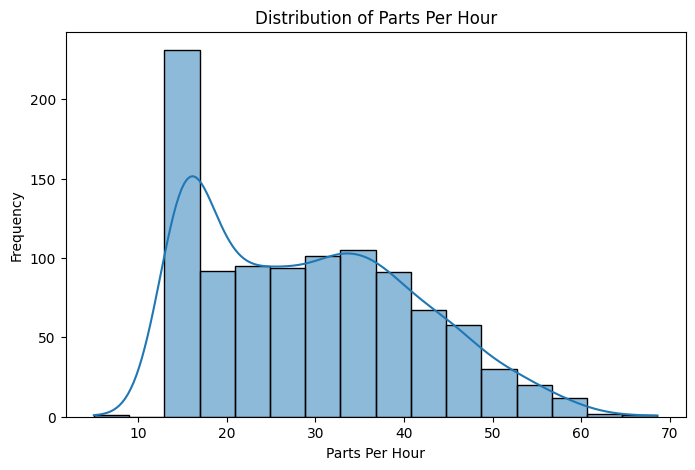

In [ ]:
#Distribution of Parts Per Hour

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))

sns.histplot(df["Parts_Per_Hour"], kde=True)

plt.title("Distribution of Parts Per Hour")
plt.xlabel("Parts Per Hour")
plt.ylabel("Frequency")

plt.show()

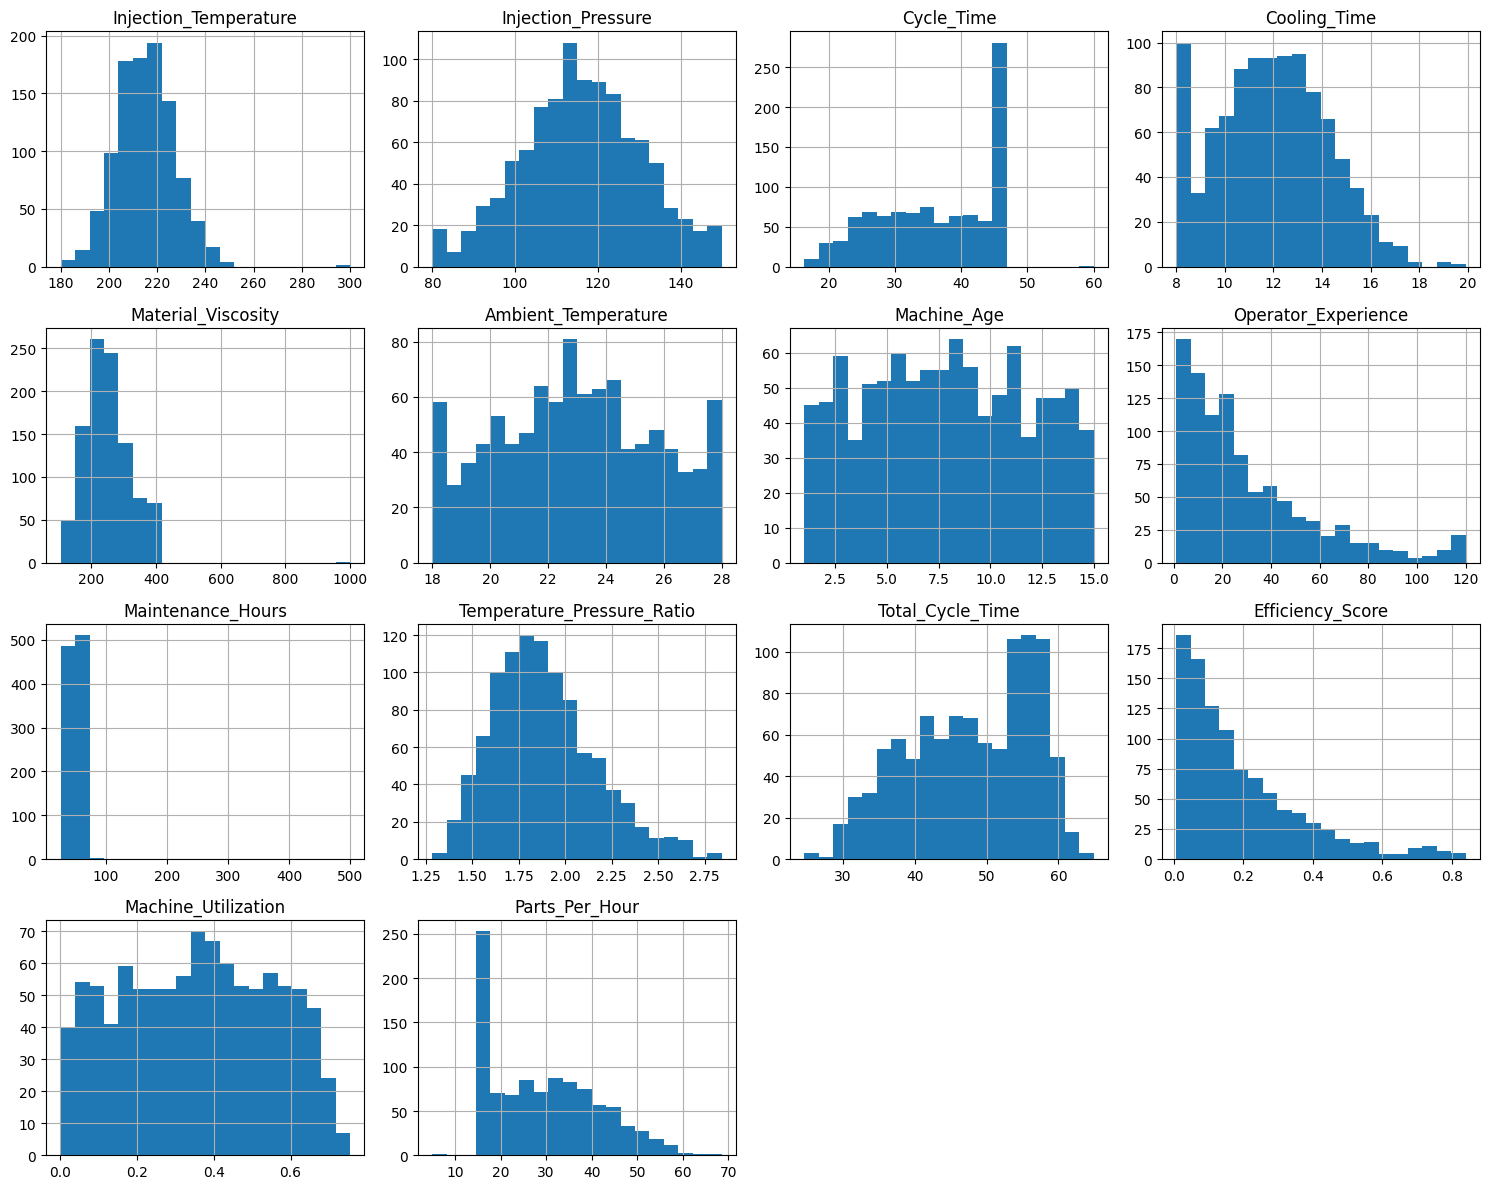

In [ ]:
#Distribution of numerical features
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

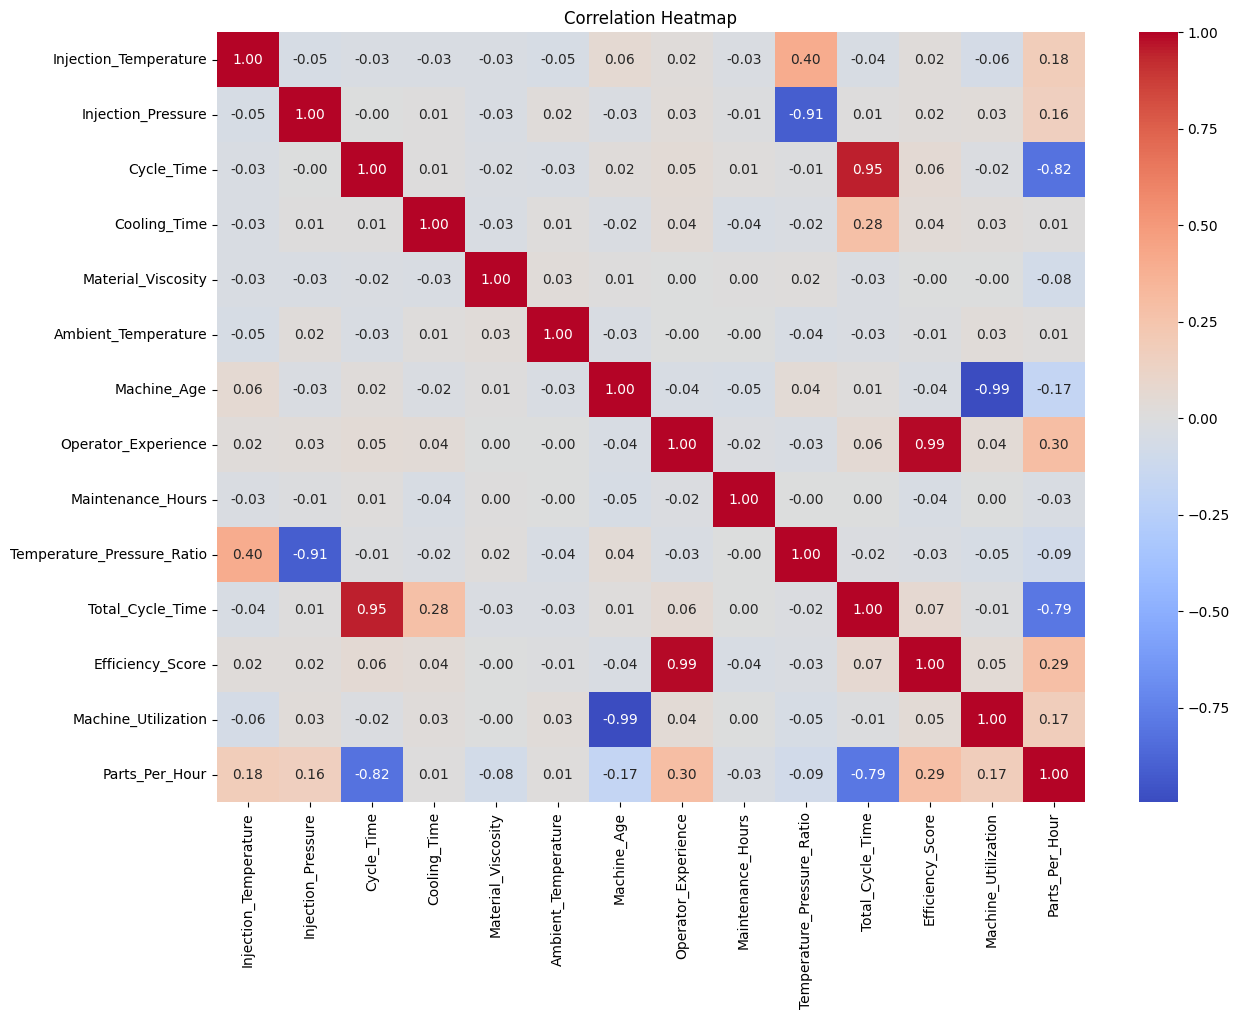

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#Finding features most correlated with target
target_correlation = (
    df[numeric_columns]
    .corr()["Parts_Per_Hour"]
    .sort_values(ascending=False)
)

print(target_correlation)

Parts_Per_Hour                1.000000
Operator_Experience           0.297100
Efficiency_Score              0.286794
Injection_Temperature         0.184353
Machine_Utilization           0.174573
Injection_Pressure            0.160362
Ambient_Temperature           0.011729
Cooling_Time                  0.006215
Maintenance_Hours            -0.032955
Material_Viscosity           -0.080036
Temperature_Pressure_Ratio   -0.086113
Machine_Age                  -0.174518
Total_Cycle_Time             -0.792862
Cycle_Time                   -0.819446
Name: Parts_Per_Hour, dtype: float64


In [ ]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_encoded = df.copy()

# Columns to encode
categorical_columns = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

# Encode each categorical column separately
label_encoders = {}

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

# Show result
df_encoded.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,1,1,0,4,1.625,42.3,0.063,0.510,36.5
1,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,2,0,2,6,1.655,48.5,0.037,0.389,29.9
2,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,0,0,2,1,1.922,29.4,0.061,0.551,56.9
3,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,1,0,1,2,2.215,52.3,0.054,0.293,31.0
4,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,2,1,1,1,1.691,54.9,0.145,0.443,15.0


In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

# Numerical input columns
numerical_columns = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Material_Viscosity",
    "Ambient_Temperature",
    "Machine_Age",
    "Operator_Experience",
    "Maintenance_Hours",
    "Temperature_Pressure_Ratio",
    "Total_Cycle_Time",
    "Efficiency_Score",
    "Machine_Utilization"
]

# Create scaler
scaler = StandardScaler()

# Scale numerical input columns
df_encoded[numerical_columns] = scaler.fit_transform(
    df_encoded[numerical_columns]
)
df_encoded.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,0.474090,1.359149,-0.856562,0.728050,1.708997,1.843582,-1.040282,-0.708301,0.838407,1,1,0,4,-0.951369,-0.627335,-0.746396,0.783359,36.5
1,-0.168139,0.874835,-0.161894,0.901726,-0.491176,-0.124033,-0.270824,-0.887005,0.463560,2,0,2,6,-0.841954,0.088037,-0.896034,0.164471,29.9
2,0.624221,-0.011937,-1.910541,-1.052130,0.765278,0.859775,-0.937688,-0.766653,-0.223658,0,0,2,1,0.131838,-2.115771,-0.757907,0.993065,56.9
3,1.499987,-0.734998,0.401027,0.510955,-1.565775,1.114836,0.344743,-0.803123,-0.098710,1,0,1,2,1.200456,0.526491,-0.798194,-0.326548,31.0
4,-0.259886,0.642910,1.095695,-0.878454,0.644042,0.240341,-0.424715,-0.277951,-0.098710,2,1,1,1,-0.710657,0.826486,-0.274460,0.440669,15.0


In [ ]:
#Define Target Variable
#target
y = df_encoded["Parts_Per_Hour"]
#fratures
X = df_encoded.drop("Parts_Per_Hour", axis=1)



In [ ]:
print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (1000, 17)
Target (y): (1000,)


In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 17)
X_test : (200, 17)
y_train: (800,)
y_test : (200,)


In [ ]:
#Linear Regression model train
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
#Testing
y_pred = model.predict(X_test)
# Compare ALL actual and predicted values

comparison = pd.DataFrame({
    "Actual_Parts_Per_Hour": y_test.values,
    "Predicted_Parts_Per_Hour": y_pred
})

comparison

,Actual_Parts_Per_Hour,Predicted_Parts_Per_Hour
0,18.6,20.446800
1,42.8,44.893186
2,34.2,32.030953
3,40.0,39.853868
4,15.0,18.226952
...,...,...
195,15.0,17.558530
196,38.7,40.480341
197,38.5,35.864711
198,28.0,28.795967


In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("---------------------------")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

Model Evaluation
---------------------------
MSE  : 13.752085646128553
RMSE : 3.708380461350824
MAE  : 2.8613933743528044
R²   : 0.8946142591530878


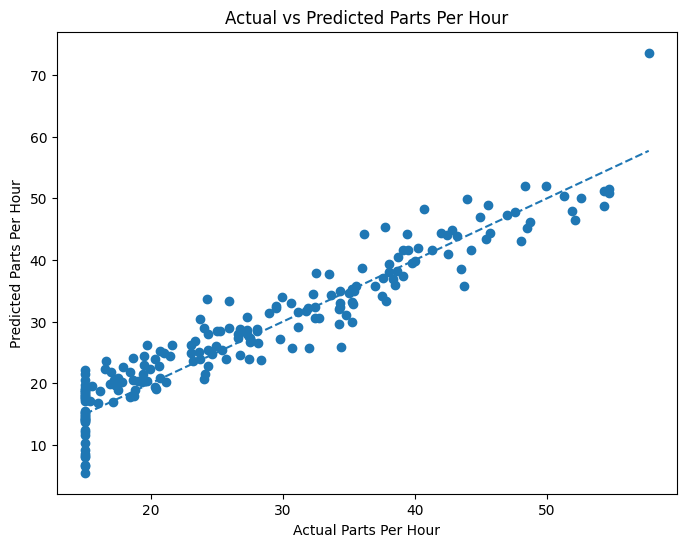

In [ ]:
# Actual vs Predicted Graph

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.title("Actual vs Predicted Parts Per Hour")

plt.show()

In [ ]:
import joblib

joblib.dump(model, "manufacturing_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("manufacturing_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# SAVE PREPROCESSING OBJECTS
# ==========================================

import joblib

# Save the trained Linear Regression model
joblib.dump(model, "model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")

# Save all LabelEncoders
joblib.dump(label_encoders, "encoders.pkl")

print("All files saved successfully!")

All files saved successfully!


In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>